# Integral Lines on a Smooth Periodic Field

We use periodic boundary conditions and compare short/medium/long integration times.


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython import get_ipython
ip = get_ipython()
if ip is not None:
    ip.run_line_magic("matplotlib", "inline")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.grid"] = True
rng = np.random.default_rng(0)
OUT = Path(".")

n = 170
x = np.linspace(0, 1, n, endpoint=False)
y = np.linspace(0, 1, n, endpoint=False)
X, Y = np.meshgrid(x, y)
u = np.sin(2*np.pi*X)*np.cos(2*np.pi*Y)
v = -np.cos(2*np.pi*X)*np.sin(2*np.pi*Y)
seeds = rng.uniform(0,1,size=(120,2))


In [2]:
def advect(T):
    P = seeds.copy()
    dt = 0.015
    steps = int(T/dt)
    traj = [P.copy()]
    for _ in range(steps):
        ix = np.mod((P[:,0]*n).astype(int), n)
        iy = np.mod((P[:,1]*n).astype(int), n)
        vel = np.c_[u[iy,ix], v[iy,ix]]
        P = np.mod(P + dt*vel, 1.0)
        traj.append(P.copy())
    return np.array(traj)

Ts = [0.3, 0.9, 1.8]
trajs = [advect(T) for T in Ts]


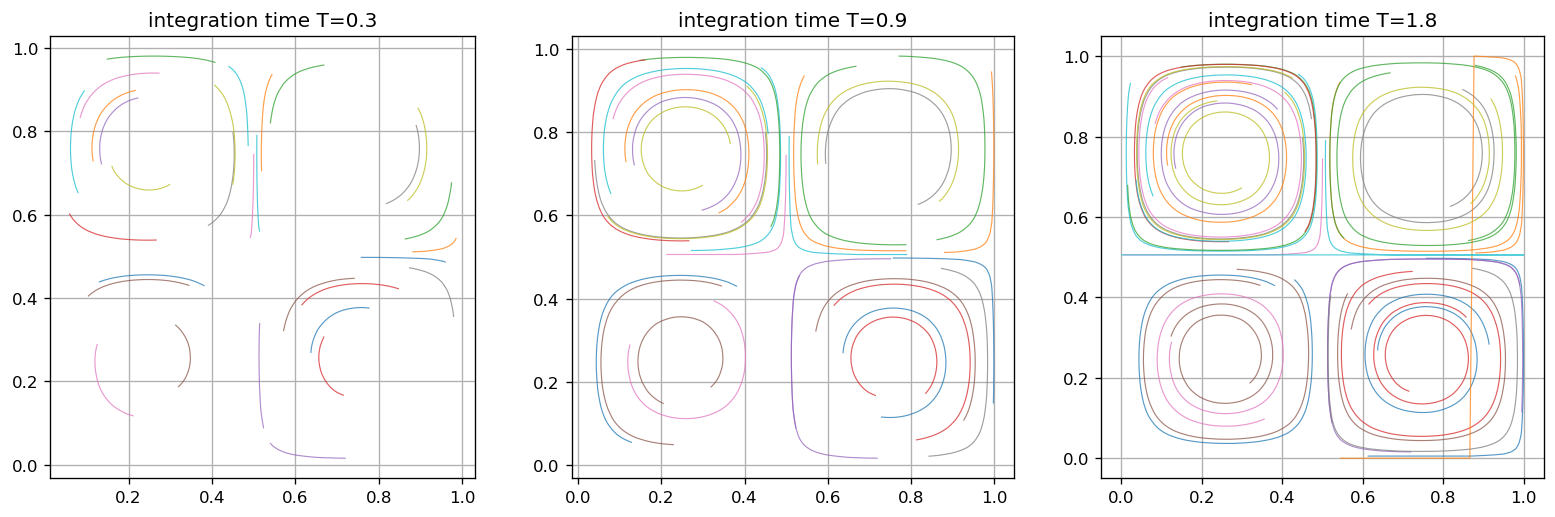

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13.2, 4.2), constrained_layout=True)
for ax, T, tr in zip(axes, Ts, trajs):
    for i in range(0, len(seeds), 4):
        ax.plot(tr[:,i,0], tr[:,i,1], lw=0.7, alpha=0.75)
    ax.set_title(f'integration time T={T}')
    ax.set_aspect('equal')
fig.savefig(OUT / "snippet.png", bbox_inches='tight')
plt.show()
